In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path('/Users/xinmingwang/Downloads/Qwen2.5-1.5B-Instruct')
CATEGORY_FILTER = None  # e.g. {'linguistic_style', 'ideology'}
PAIR_FILTER = None  # e.g. {'linguistic_style__concise__verbose'}

assert ROOT.exists(), f'Not found: {ROOT}'
ROOT


PosixPath('/Users/xinmingwang/Downloads/Qwen2.5-1.5B-Instruct')

In [3]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return np.nan
    return float(np.dot(a, b) / denom)


def layer_index_map(layers: list[int]) -> dict[int, int]:
    """Map stored zero-based layer ids to plot order: 1 = layer 0, max = last layer."""
    return {layer: idx for idx, layer in enumerate(sorted(layers), start=1)}


def parse_pair_dir(pair_dir: Path) -> dict:
    metadata_path = pair_dir / 'metadata.json'
    metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
    examples = metadata.get('examples', [])
    first_example = examples[0] if examples else {}

    return {
        'pair_dir': pair_dir,
        'category_key': first_example.get('category_key', pair_dir.parent.name),
        'category_name': first_example.get('category_name', pair_dir.parent.name),
        'pair_slug': first_example.get('pair_slug', pair_dir.name),
        'positive_concept': first_example.get('positive_concept', ''),
        'negative_concept': first_example.get('negative_concept', ''),
        'layers': metadata['run_config']['hidden_layers'],
        'variant_counts': metadata.get('variant_counts', {}),
    }


def iter_pair_infos(root: Path):
    for category_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        if CATEGORY_FILTER and category_dir.name not in CATEGORY_FILTER:
            continue
        for pair_dir in sorted(path for path in category_dir.iterdir() if path.is_dir()):
            if PAIR_FILTER and pair_dir.name not in PAIR_FILTER:
                continue
            metadata_path = pair_dir / 'metadata.json'
            if metadata_path.exists():
                yield parse_pair_dir(pair_dir)


def load_layer_matrix(pair_dir: Path, variant: str, layer: int) -> np.ndarray:
    layer_path = pair_dir / variant / f'layer_{layer}.npy'
    return np.load(layer_path)


def build_steering_results(root: Path):
    rows = []
    steering_vectors = {}

    for pair_info in iter_pair_infos(root):
        pair_dir = pair_info['pair_dir']
        pair_slug = pair_info['pair_slug']
        layer_to_index = layer_index_map(pair_info['layers'])
        steering_vectors[pair_slug] = {}

        for layer in sorted(pair_info['layers']):
            positive = load_layer_matrix(pair_dir, 'positive', layer)
            base = load_layer_matrix(pair_dir, 'base', layer)
            negative = load_layer_matrix(pair_dir, 'negative', layer)

            pos_minus_base = positive.mean(axis=0) - base.mean(axis=0)
            neg_minus_base = negative.mean(axis=0) - base.mean(axis=0)
            cos_sim = cosine_similarity(pos_minus_base, neg_minus_base)

            steering_vectors[pair_slug][layer] = {
                'layer_index': layer_to_index[layer],
                'pos_minus_base': pos_minus_base,
                'neg_minus_base': neg_minus_base,
            }

            rows.append({
                'category_key': pair_info['category_key'],
                'category_name': pair_info['category_name'],
                'pair_slug': pair_slug,
                'concept_label': f"{pair_info['positive_concept']} vs {pair_info['negative_concept']}",
                'positive_concept': pair_info['positive_concept'],
                'negative_concept': pair_info['negative_concept'],
                'layer': layer,
                'layer_index': layer_to_index[layer],
                'n_layers': len(pair_info['layers']),
                'n_positive': positive.shape[0],
                'n_base': base.shape[0],
                'n_negative': negative.shape[0],
                'hidden_dim': positive.shape[1],
                'pos_base_norm': float(np.linalg.norm(pos_minus_base)),
                'neg_base_norm': float(np.linalg.norm(neg_minus_base)),
                'cos_similarity': cos_sim,
            })

    results_df = pd.DataFrame(rows).sort_values(['layer_index', 'category_key', 'pair_slug'])
    return results_df.reset_index(drop=True), steering_vectors


def plot_pair_cosine(results_df: pd.DataFrame, pair_slug: str, ax=None):
    pair_df = results_df.loc[results_df['pair_slug'] == pair_slug].sort_values('layer_index')
    if pair_df.empty:
        raise ValueError(f'Unknown pair_slug: {pair_slug}')

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    ax.plot(pair_df['layer_index'], pair_df['cos_similarity'], marker='o', linewidth=1.5)
    ax.axhline(0.0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_xlabel('Layer index (1 = layer 0, larger = later layer)')
    ax.set_ylabel('cos(pos-base, neg-base)')
    ax.set_title(pair_df['concept_label'].iloc[0])
    ax.grid(alpha=0.25)
    return ax


def make_cosine_heatmap(results_df: pd.DataFrame, category_key: str | None = None, figsize=(12, 18)):
    subset = results_df.copy()
    if category_key is not None:
        subset = subset.loc[subset['category_key'] == category_key]

    heatmap_df = subset.pivot(index='concept_label', columns='layer_index', values='cos_similarity')
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heatmap_df.to_numpy(), aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    ax.set_xlabel('Layer index (1 = layer 0, larger = later layer)')
    ax.set_ylabel('Concept pair')
    ax.set_title('cos(pos-base, neg-base)' if category_key is None else f'{category_key}: cos(pos-base, neg-base)')
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    return heatmap_df

In [4]:
results_df, steering_vectors = build_steering_results(ROOT)

print(f'Loaded {results_df["pair_slug"].nunique()} pairs across {results_df["category_key"].nunique()} categories')
print(f'Layers per pair: {results_df["layer_index"].nunique()}')
display(results_df.head())

Loaded 150 pairs across 3 categories
Layers per pair: 28


,category_key,category_name,pair_slug,concept_label,positive_concept,negative_concept,layer,layer_index,n_layers,n_positive,n_base,n_negative,hidden_dim,pos_base_norm,neg_base_norm,cos_similarity
0,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,0,1,28,100,100,100,1536,1.979170,1.749771,0.953213
1,ideology,IDEOLOGY,ideology__collective_benefit__personal_benefit,collective-benefit vs personal-benefit,collective-benefit,personal-benefit,0,1,28,100,100,100,1536,1.900831,1.670067,0.938003
2,ideology,IDEOLOGY,ideology__collective_responsibility__individua...,collective-responsibility vs individual-respon...,collective-responsibility,individual-responsibility,0,1,28,100,100,100,1536,2.296770,2.071911,0.962225
3,ideology,IDEOLOGY,ideology__collective_security__civil_liberty,collective-security vs civil-liberty,collective-security,civil-liberty,0,1,28,100,100,100,1536,1.494647,1.726147,0.873227
4,ideology,IDEOLOGY,ideology__collective_welfare__individual_liberty,collective-welfare vs individual-liberty,collective-welfare,individual-liberty,0,1,28,100,100,100,1536,1.935454,1.664102,0.940299


In [5]:
results_normal_order = results_df.sort_values(['layer_index', 'category_key', 'pair_slug']).reset_index(drop=True)

layer_summary = (
    results_df.groupby('layer_index', as_index=False)
    .agg(
        mean_cos_similarity=('cos_similarity', 'mean'),
        median_cos_similarity=('cos_similarity', 'median'),
        mean_pos_base_norm=('pos_base_norm', 'mean'),
        mean_neg_base_norm=('neg_base_norm', 'mean'),
        num_pairs=('pair_slug', 'nunique'),
    )
    .sort_values('layer_index')
)

display(layer_summary)
display(results_normal_order[[
    'category_key',
    'concept_label',
    'layer_index',
    'layer',
    'cos_similarity',
    'pos_base_norm',
    'neg_base_norm',
]].head(50))

,layer_index,mean_cos_similarity,median_cos_similarity,mean_pos_base_norm,mean_neg_base_norm,num_pairs
0,1,0.898064,0.900062,1.636164,1.443123,150
1,2,0.903120,0.906901,2.204106,1.915742,150
2,3,0.905911,0.911660,2.471838,2.115480,150
3,4,0.921227,0.924687,3.088087,2.738585,150
4,5,0.924282,0.925843,3.169071,2.858437,150
5,6,0.932642,0.935172,3.128958,2.904716,150
6,7,0.944511,0.946450,3.258834,3.136031,150
7,8,0.945537,0.946568,3.640663,3.594734,150
8,9,0.945117,0.947336,3.588573,3.634419,150
9,10,0.948032,0.952042,3.935862,4.039155,150


,category_key,concept_label,layer_index,layer,cos_similarity,pos_base_norm,neg_base_norm
0,ideology,centralization-support vs decentralization-sup...,1,0,0.953213,1.979170,1.749771
1,ideology,collective-benefit vs personal-benefit,1,0,0.938003,1.900831,1.670067
2,ideology,collective-responsibility vs individual-respon...,1,0,0.962225,2.296770,2.071911
3,ideology,collective-security vs civil-liberty,1,0,0.873227,1.494647,1.726147
4,ideology,collective-welfare vs individual-liberty,1,0,0.940299,1.935454,1.664102
5,ideology,competition-policy vs cooperation-policy,1,0,0.928136,1.610075,1.259412
6,ideology,consumer-protection vs corporate-freedom,1,0,0.938070,1.975654,2.079884
7,ideology,data-protection-priority vs data-utilization-p...,1,0,0.968125,2.404849,2.219603
8,ideology,economic-growth-priority vs sustainability-pri...,1,0,0.950441,2.519923,1.904701
9,ideology,energy-transition vs fossil-energy-support,1,0,0.896325,1.567531,1.843117


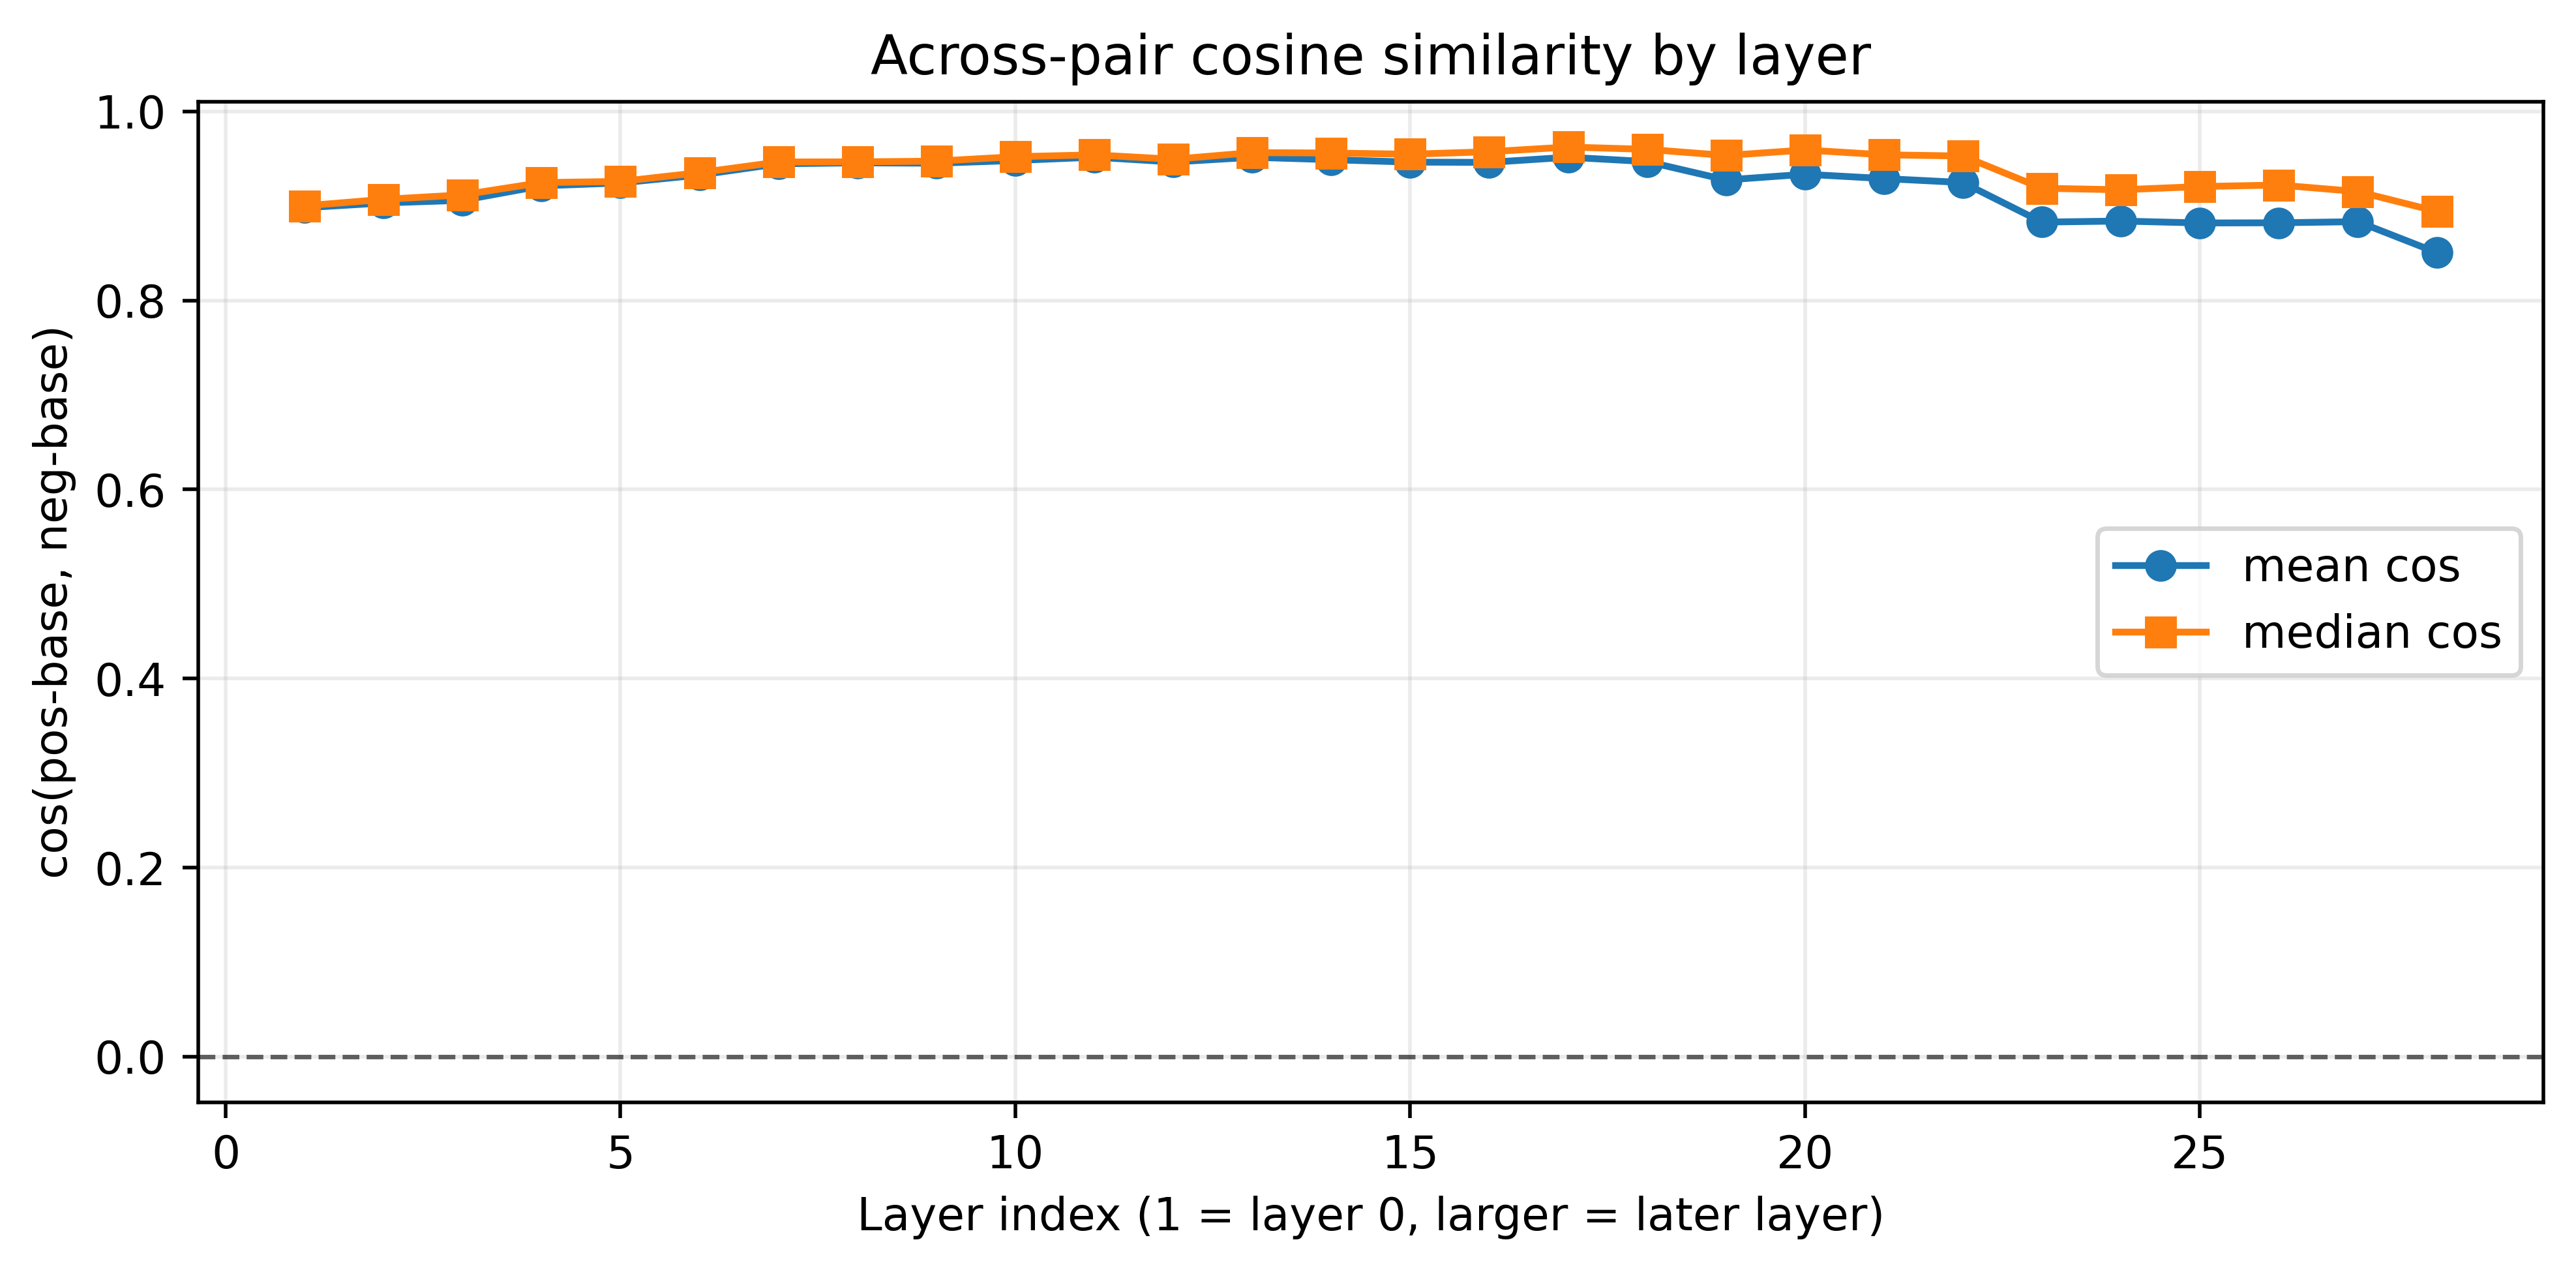

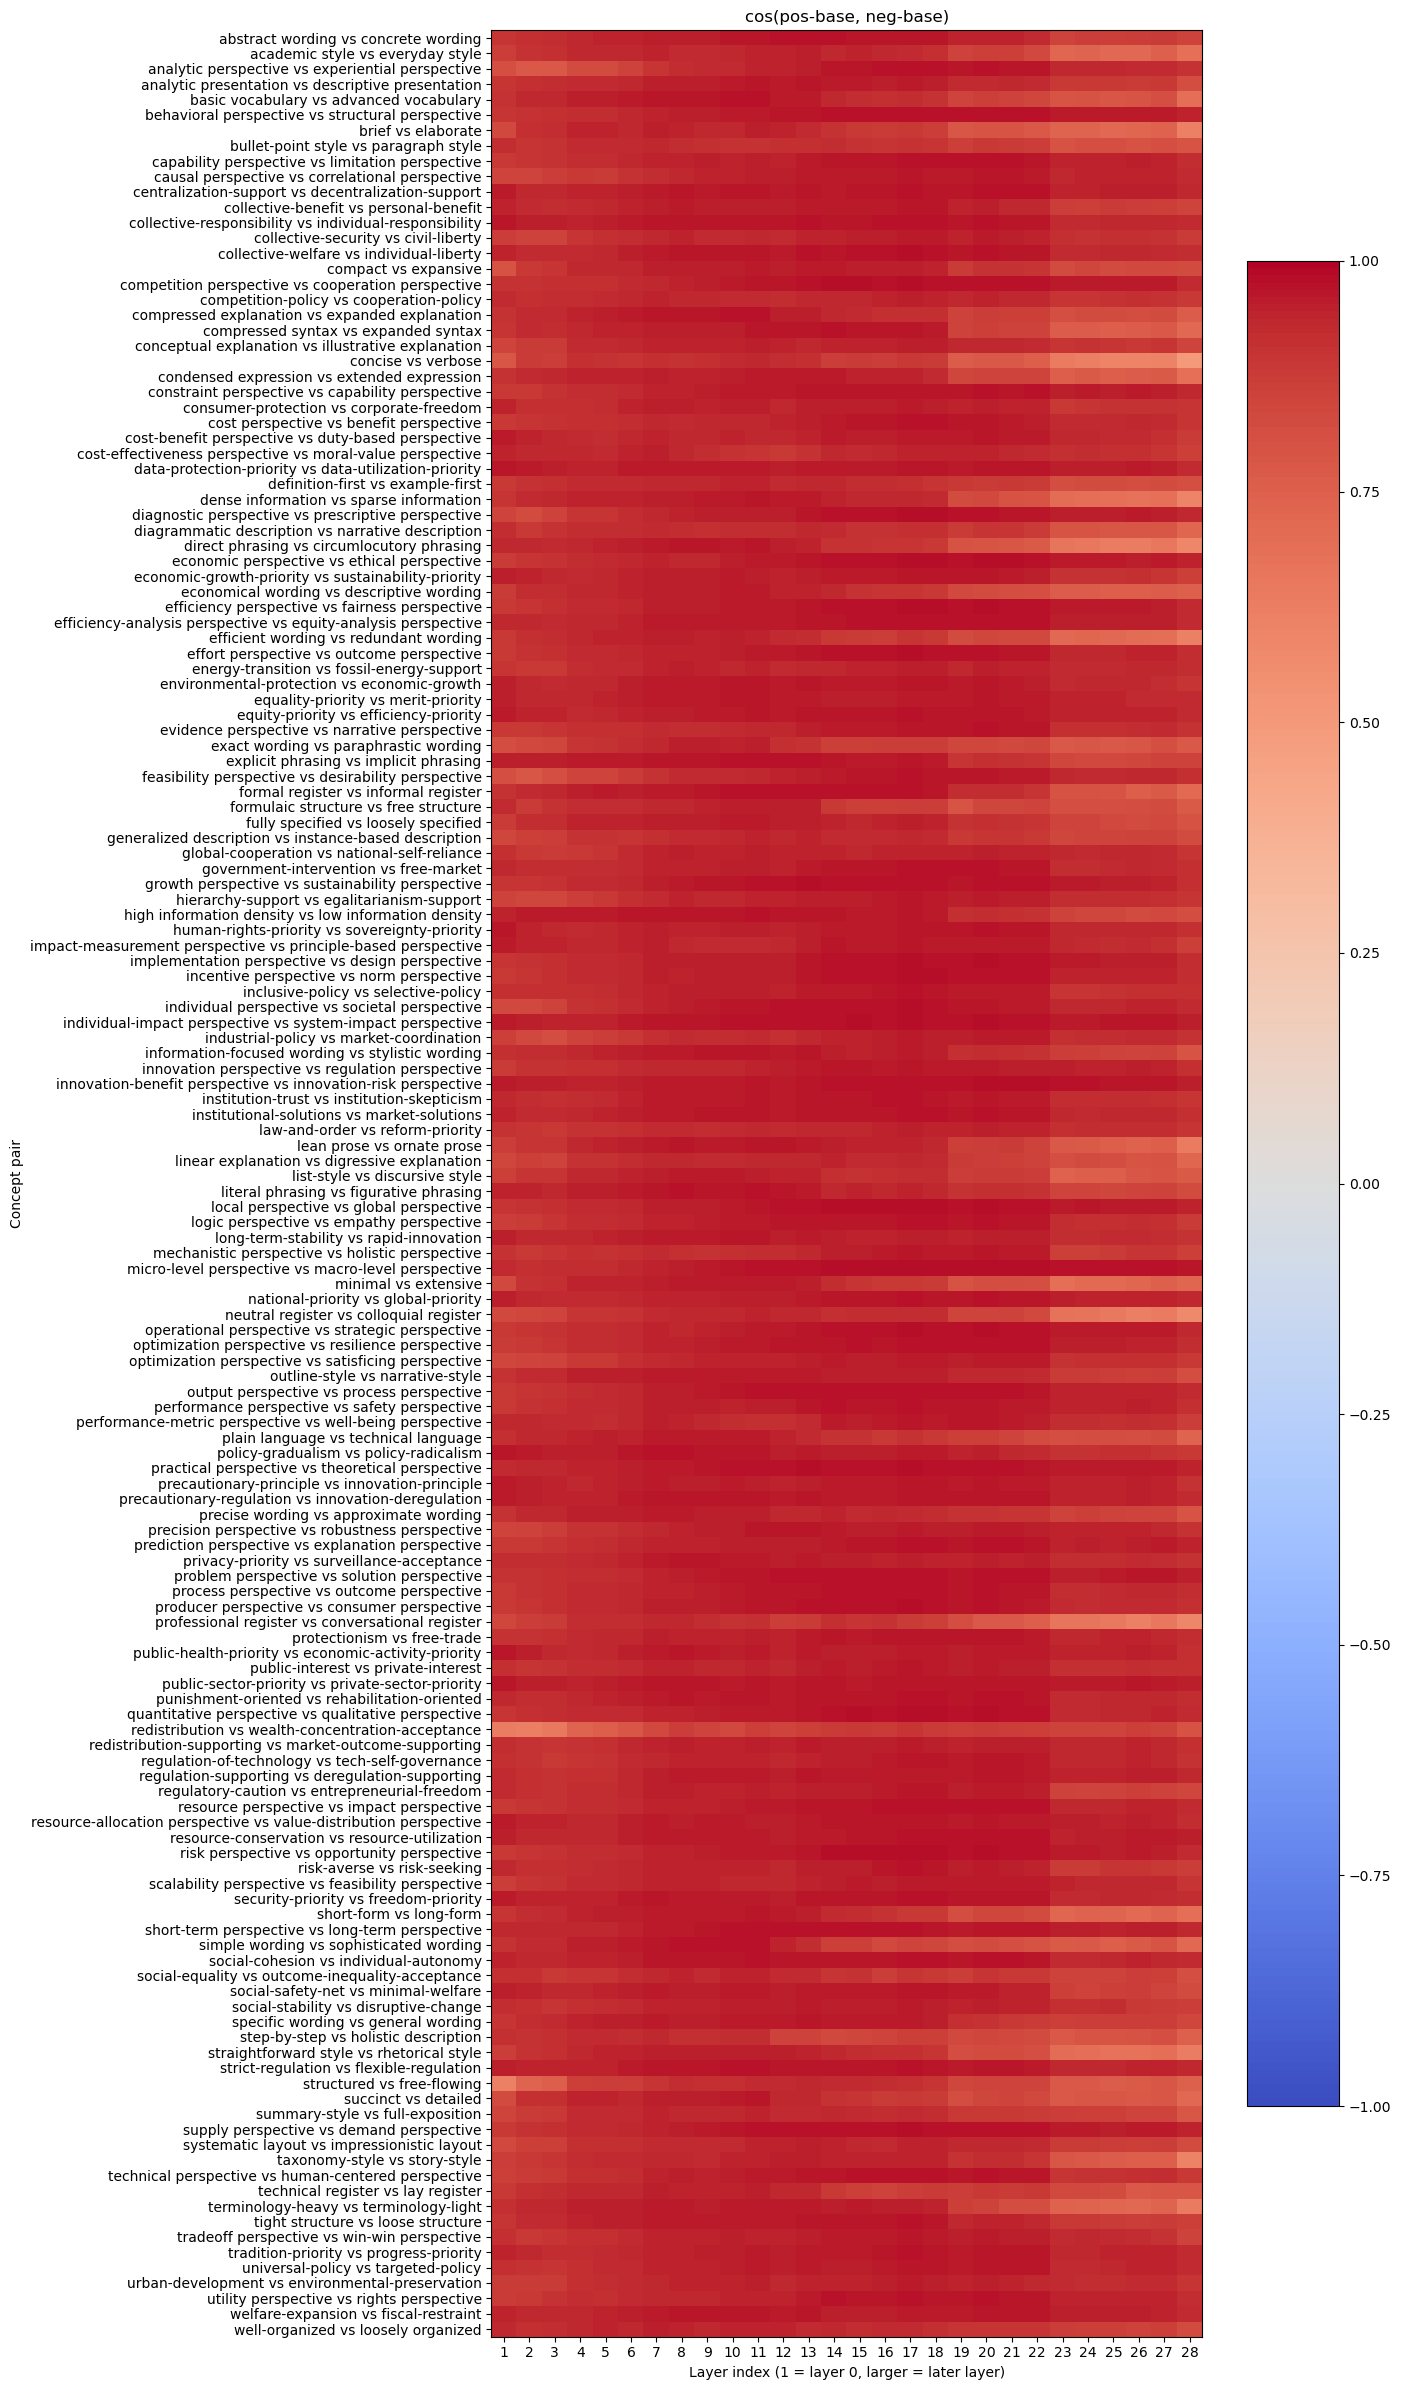

In [6]:
plt.figure(figsize=(8, 4), dpi=500)
plt.plot(layer_summary['layer_index'], layer_summary['mean_cos_similarity'], marker='o', label='mean cos')
plt.plot(layer_summary['layer_index'], layer_summary['median_cos_similarity'], marker='s', label='median cos')
plt.axhline(0.0, color='black', linewidth=1, linestyle='--', alpha=0.6)
plt.xlabel('Layer index (1 = layer 0, larger = later layer)')
plt.ylabel('cos(pos-base, neg-base)')
plt.title('Across-pair cosine similarity by layer')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

make_cosine_heatmap(results_df, figsize=(14, 24));

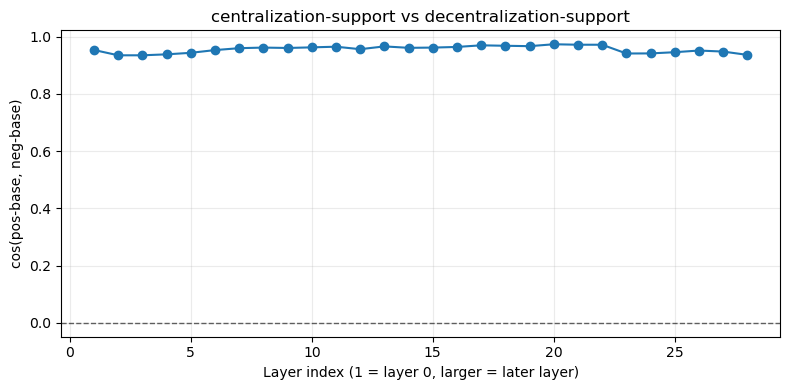

,category_key,concept_label,layer_index,layer,cos_similarity,pos_base_norm,neg_base_norm
0,ideology,centralization-support vs decentralization-sup...,1,0,0.953213,1.979170,1.749771
150,ideology,centralization-support vs decentralization-sup...,2,1,0.934681,2.400628,2.070216
300,ideology,centralization-support vs decentralization-sup...,3,2,0.934696,2.630663,2.225329
450,ideology,centralization-support vs decentralization-sup...,4,3,0.938050,3.121198,2.649620
600,ideology,centralization-support vs decentralization-sup...,5,4,0.943397,3.226260,2.789105
750,ideology,centralization-support vs decentralization-sup...,6,5,0.952939,3.325805,2.924476
900,ideology,centralization-support vs decentralization-sup...,7,6,0.959605,3.449644,3.149528
1050,ideology,centralization-support vs decentralization-sup...,8,7,0.961664,3.826748,3.530820
1200,ideology,centralization-support vs decentralization-sup...,9,8,0.960313,3.709310,3.460585
1350,ideology,centralization-support vs decentralization-sup...,10,9,0.962459,3.878314,3.709885


In [7]:
pair_slug = results_df['pair_slug'].iloc[0]
pair_slug

plot_pair_cosine(results_df, pair_slug)
plt.tight_layout()
plt.show()

display(
    results_df.loc[results_df['pair_slug'] == pair_slug, [
        'category_key',
        'concept_label',
        'layer_index',
        'layer',
        'cos_similarity',
        'pos_base_norm',
        'neg_base_norm',
    ]].sort_values('layer_index')
)

In [8]:
def build_contrast_sanity_results(root: Path):
    rows = []
    contrast_vectors = {}

    for pair_info in iter_pair_infos(root):
        pair_dir = pair_info['pair_dir']
        pair_slug = pair_info['pair_slug']
        layer_to_index = layer_index_map(pair_info['layers'])
        contrast_vectors[pair_slug] = {}

        for layer in sorted(pair_info['layers']):
            positive = load_layer_matrix(pair_dir, 'positive', layer)
            base = load_layer_matrix(pair_dir, 'base', layer)
            negative = load_layer_matrix(pair_dir, 'negative', layer)

            pos_mean = positive.mean(axis=0)
            base_mean = base.mean(axis=0)
            neg_mean = negative.mean(axis=0)

            pos_base = pos_mean - base_mean
            neg_base = neg_mean - base_mean

            # Shared shift: what positive and negative both do relative to base.
            shared = ((pos_mean + neg_mean) / 2.0) - base_mean

            # Contrast shift: what separates positive from negative directly.
            contrast = pos_mean - neg_mean

            shared_sq_norm = float(np.dot(shared, shared))
            if shared_sq_norm == 0.0:
                contrast_clean = contrast.copy()
                contrast_shared_projection_norm = 0.0
            else:
                contrast_projection_on_shared = shared * (np.dot(contrast, shared) / shared_sq_norm)
                contrast_clean = contrast - contrast_projection_on_shared
                contrast_shared_projection_norm = float(np.linalg.norm(contrast_projection_on_shared))

            contrast_norm = float(np.linalg.norm(contrast))
            shared_norm = float(np.linalg.norm(shared))
            contrast_clean_norm = float(np.linalg.norm(contrast_clean))

            contrast_vectors[pair_slug][layer] = {
                'layer_index': layer_to_index[layer],
                'shared': shared,
                'contrast': contrast,
                'contrast_clean': contrast_clean,
            }

            rows.append({
                'category_key': pair_info['category_key'],
                'category_name': pair_info['category_name'],
                'pair_slug': pair_slug,
                'concept_label': f"{pair_info['positive_concept']} vs {pair_info['negative_concept']}",
                'positive_concept': pair_info['positive_concept'],
                'negative_concept': pair_info['negative_concept'],
                'layer': layer,
                'layer_index': layer_to_index[layer],
                'n_layers': len(pair_info['layers']),
                'hidden_dim': positive.shape[1],
                'pos_base_norm': float(np.linalg.norm(pos_base)),
                'neg_base_norm': float(np.linalg.norm(neg_base)),
                'shared_norm': shared_norm,
                'contrast_norm': contrast_norm,
                'contrast_clean_norm': contrast_clean_norm,
                'contrast_to_shared_cos': cosine_similarity(contrast, shared),
                'abs_contrast_shared_cos': abs(cosine_similarity(contrast, shared)),
                'contrast_clean_to_shared_cos': cosine_similarity(contrast_clean, shared),
                'contrast_to_shared_norm_ratio': contrast_norm / shared_norm if shared_norm else np.nan,
                'contrast_clean_to_contrast_norm_ratio': contrast_clean_norm / contrast_norm if contrast_norm else np.nan,
                'contrast_shared_projection_norm': contrast_shared_projection_norm,
            })

    contrast_df = pd.DataFrame(rows).sort_values(['layer_index', 'category_key', 'pair_slug'])
    return contrast_df.reset_index(drop=True), contrast_vectors


contrast_df, contrast_vectors = build_contrast_sanity_results(ROOT)

contrast_layer_summary = (
    contrast_df.groupby('layer_index', as_index=False)
    .agg(
        mean_shared_norm=('shared_norm', 'mean'),
        mean_contrast_norm=('contrast_norm', 'mean'),
        mean_contrast_clean_norm=('contrast_clean_norm', 'mean'),
        mean_abs_contrast_shared_cos=('abs_contrast_shared_cos', 'mean'),
        median_abs_contrast_shared_cos=('abs_contrast_shared_cos', 'median'),
        mean_contrast_to_shared_norm_ratio=('contrast_to_shared_norm_ratio', 'mean'),
        num_pairs=('pair_slug', 'nunique'),
    )
    .sort_values('layer_index')
)

display(contrast_layer_summary)
display(contrast_df[[
    'category_key',
    'concept_label',
    'layer_index',
    'layer',
    'contrast_to_shared_cos',
    'abs_contrast_shared_cos',
    'contrast_norm',
    'shared_norm',
    'contrast_to_shared_norm_ratio',
    'contrast_clean_to_contrast_norm_ratio',
]].head(50))

,layer_index,mean_shared_norm,mean_contrast_norm,mean_contrast_clean_norm,mean_abs_contrast_shared_cos,median_abs_contrast_shared_cos,mean_contrast_to_shared_norm_ratio,num_pairs
0,1,1.502849,0.748771,0.642568,0.461475,0.475423,0.518983,150
1,2,2.010622,0.977302,0.872858,0.402367,0.441526,0.492694,150
2,3,2.239807,1.080884,0.965999,0.404318,0.462671,0.486284,150
3,4,2.855859,1.212315,1.136276,0.316451,0.347534,0.426447,150
4,5,2.956623,1.216073,1.153415,0.286978,0.318463,0.413150,150
5,6,2.966009,1.144437,1.089692,0.269037,0.272102,0.387226,150
6,7,3.153066,1.087405,1.050878,0.216572,0.194190,0.345824,150
7,8,3.568370,1.211046,1.179795,0.169273,0.130729,0.340130,150
8,9,3.561739,1.208856,1.182092,0.152078,0.113555,0.339837,150
9,10,3.935433,1.295128,1.267496,0.150652,0.128721,0.329391,150


,category_key,concept_label,layer_index,layer,contrast_to_shared_cos,abs_contrast_shared_cos,contrast_norm,shared_norm,contrast_to_shared_norm_ratio,contrast_clean_to_contrast_norm_ratio
0,ideology,centralization-support vs decentralization-sup...,1,0,0.378203,0.378203,0.613742,1.842617,0.333082,0.925723
1,ideology,collective-benefit vs personal-benefit,1,0,0.350658,0.350658,0.668486,1.757675,0.380324,0.936503
2,ideology,collective-responsibility vs individual-respon...,1,0,0.354492,0.354492,0.640376,2.163669,0.295968,0.935059
3,ideology,collective-security vs civil-liberty,1,0,-0.284288,0.284288,0.841272,1.558795,0.539693,0.958739
4,ideology,collective-welfare vs individual-liberty,1,0,0.406955,0.406955,0.676906,1.772867,0.381815,0.913448
5,ideology,competition-policy vs cooperation-policy,1,0,0.554627,0.554627,0.643746,1.409123,0.456841,0.832099
6,ideology,consumer-protection vs corporate-freedom,1,0,-0.146856,0.146856,0.720985,1.996149,0.361188,0.989158
7,ideology,data-protection-priority vs data-utilization-p...,1,0,0.305107,0.305107,0.612043,2.293756,0.266830,0.952318
8,ideology,economic-growth-priority vs sustainability-pri...,1,0,0.673883,0.673883,0.924250,2.185267,0.422946,0.738838
9,ideology,energy-transition vs fossil-energy-support,1,0,-0.344416,0.344416,0.821590,1.660833,0.494686,0.938817


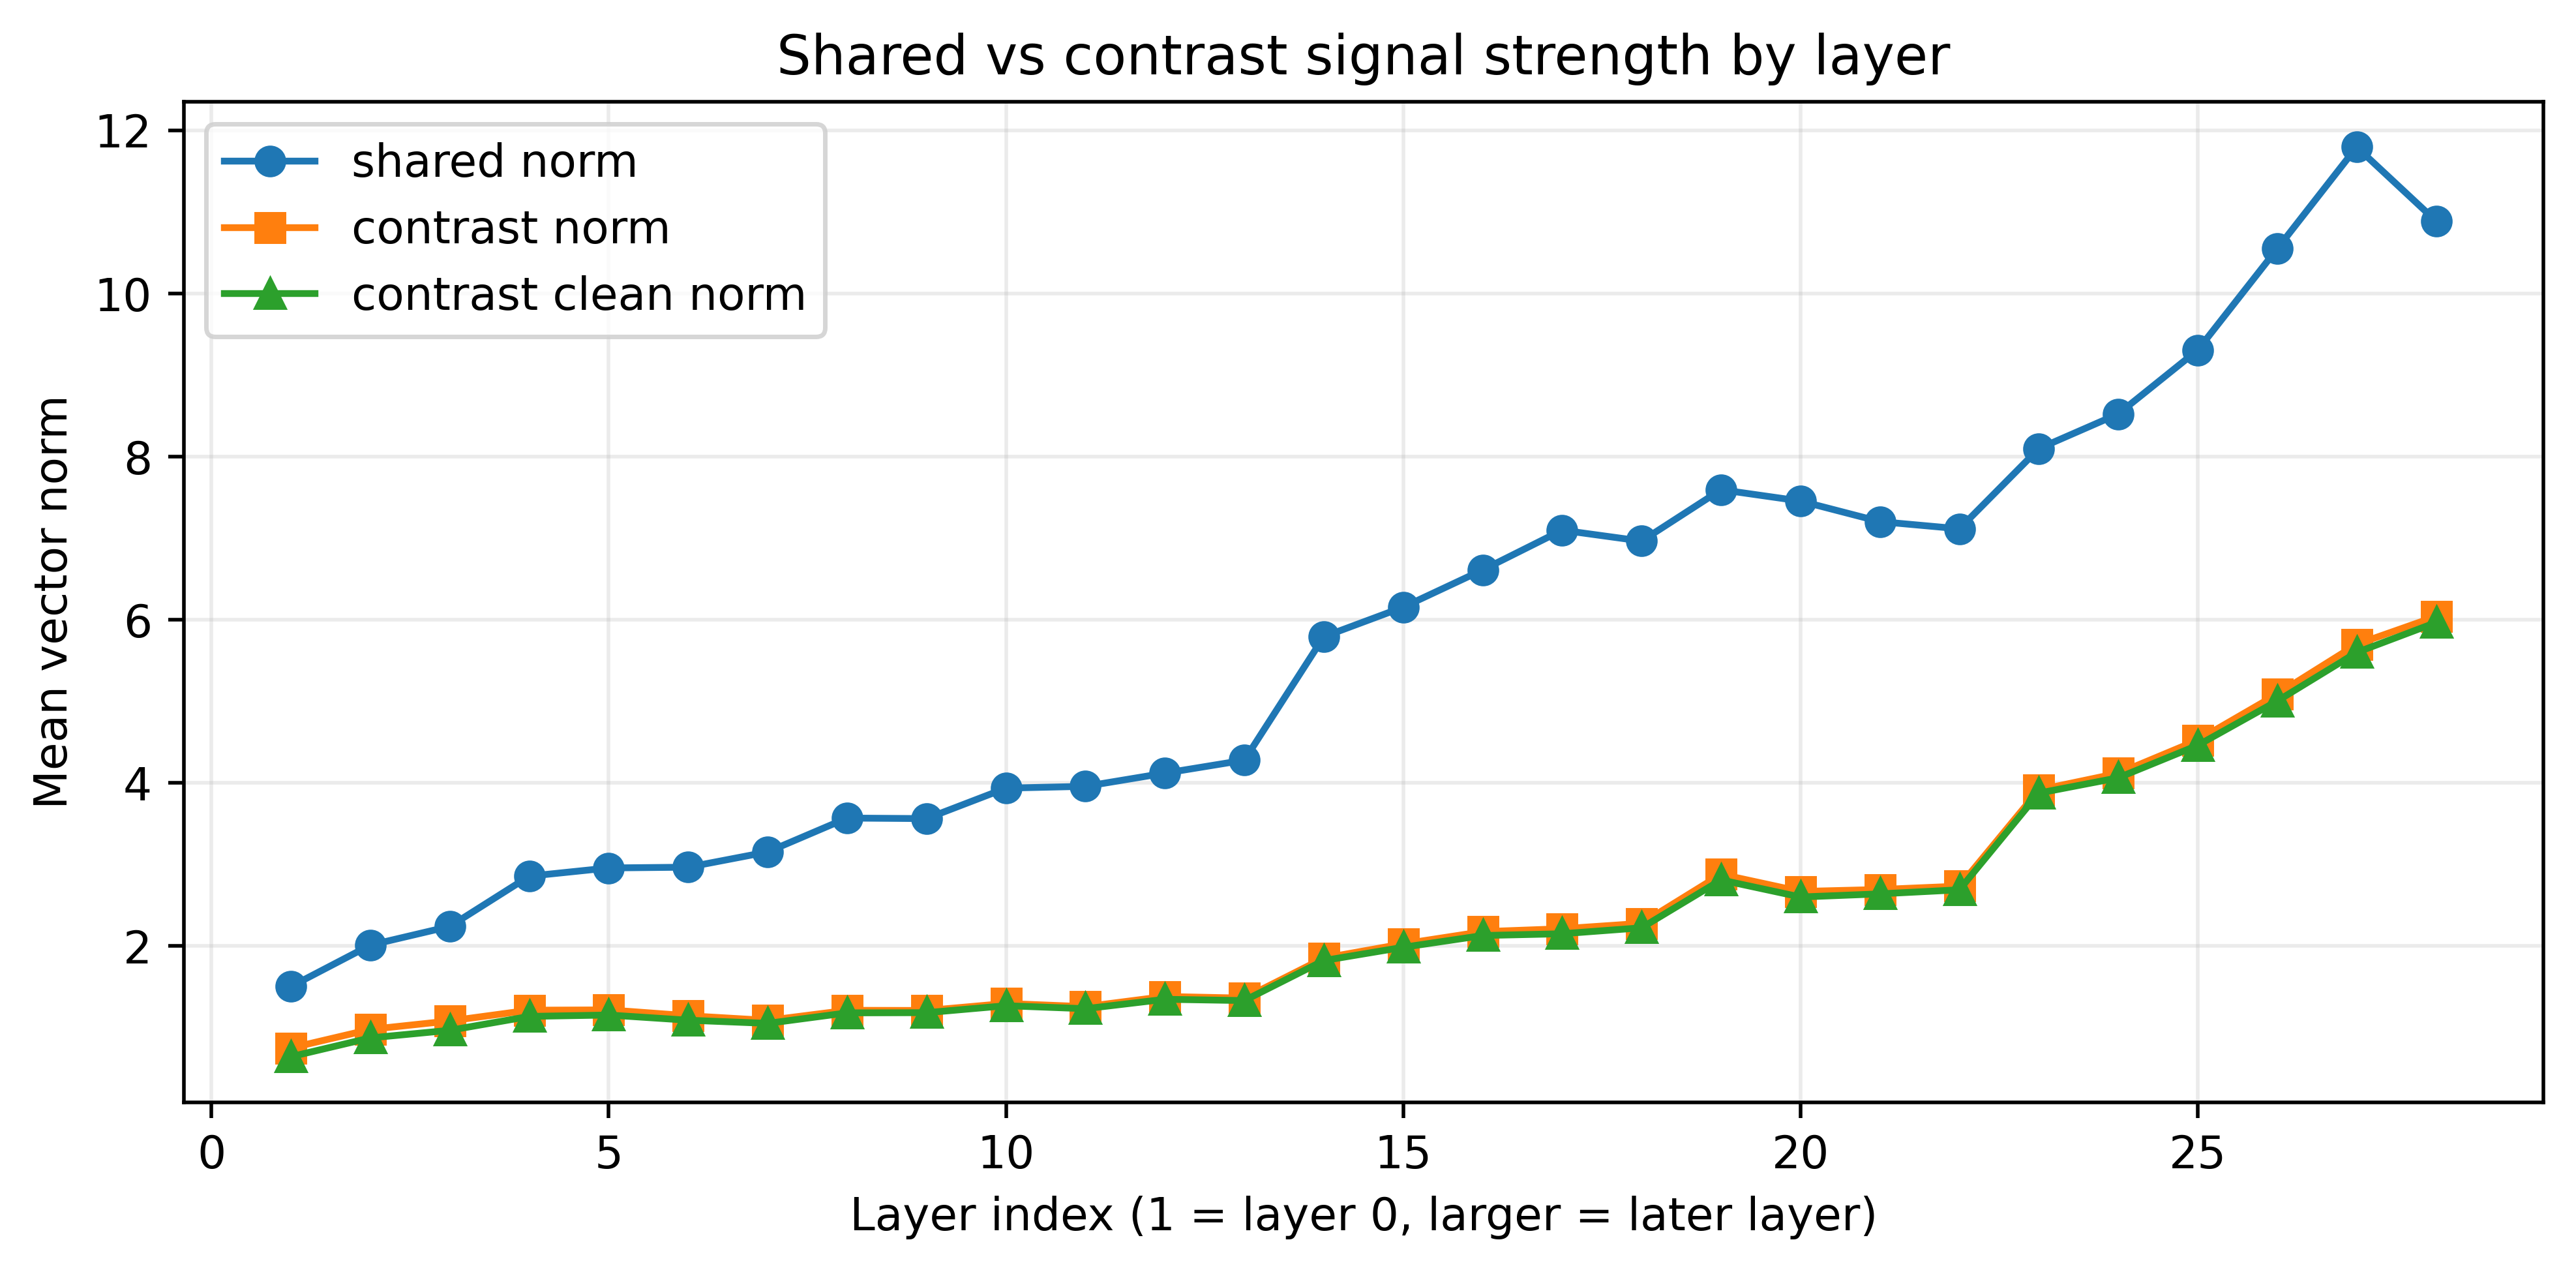

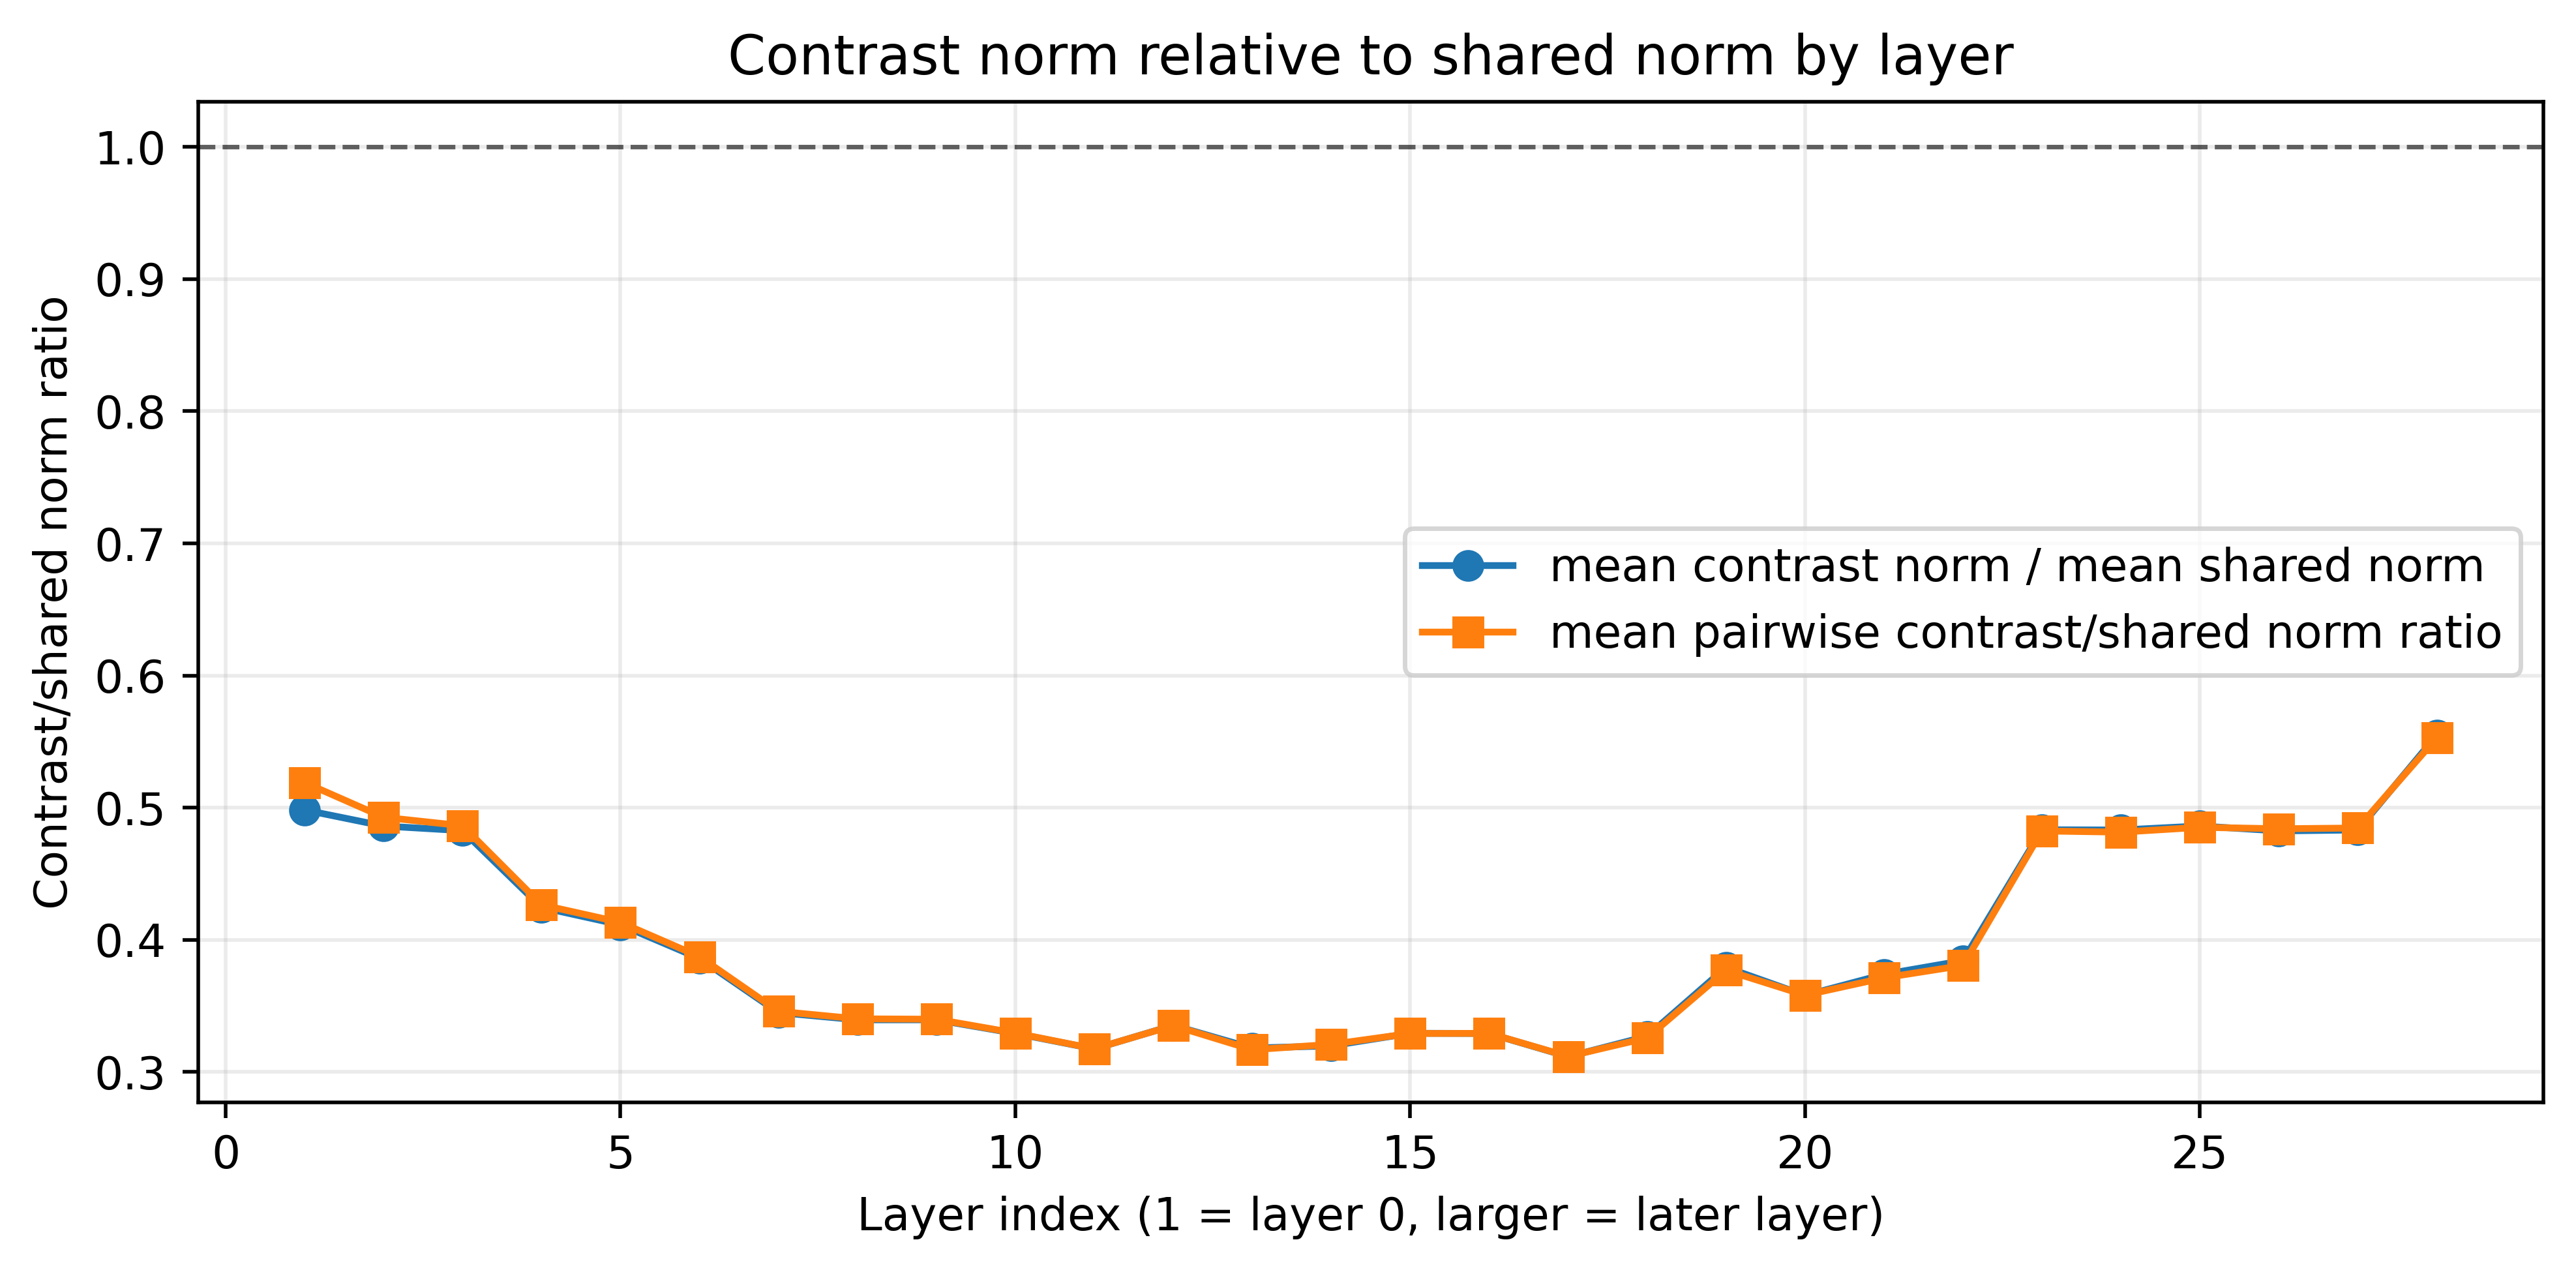

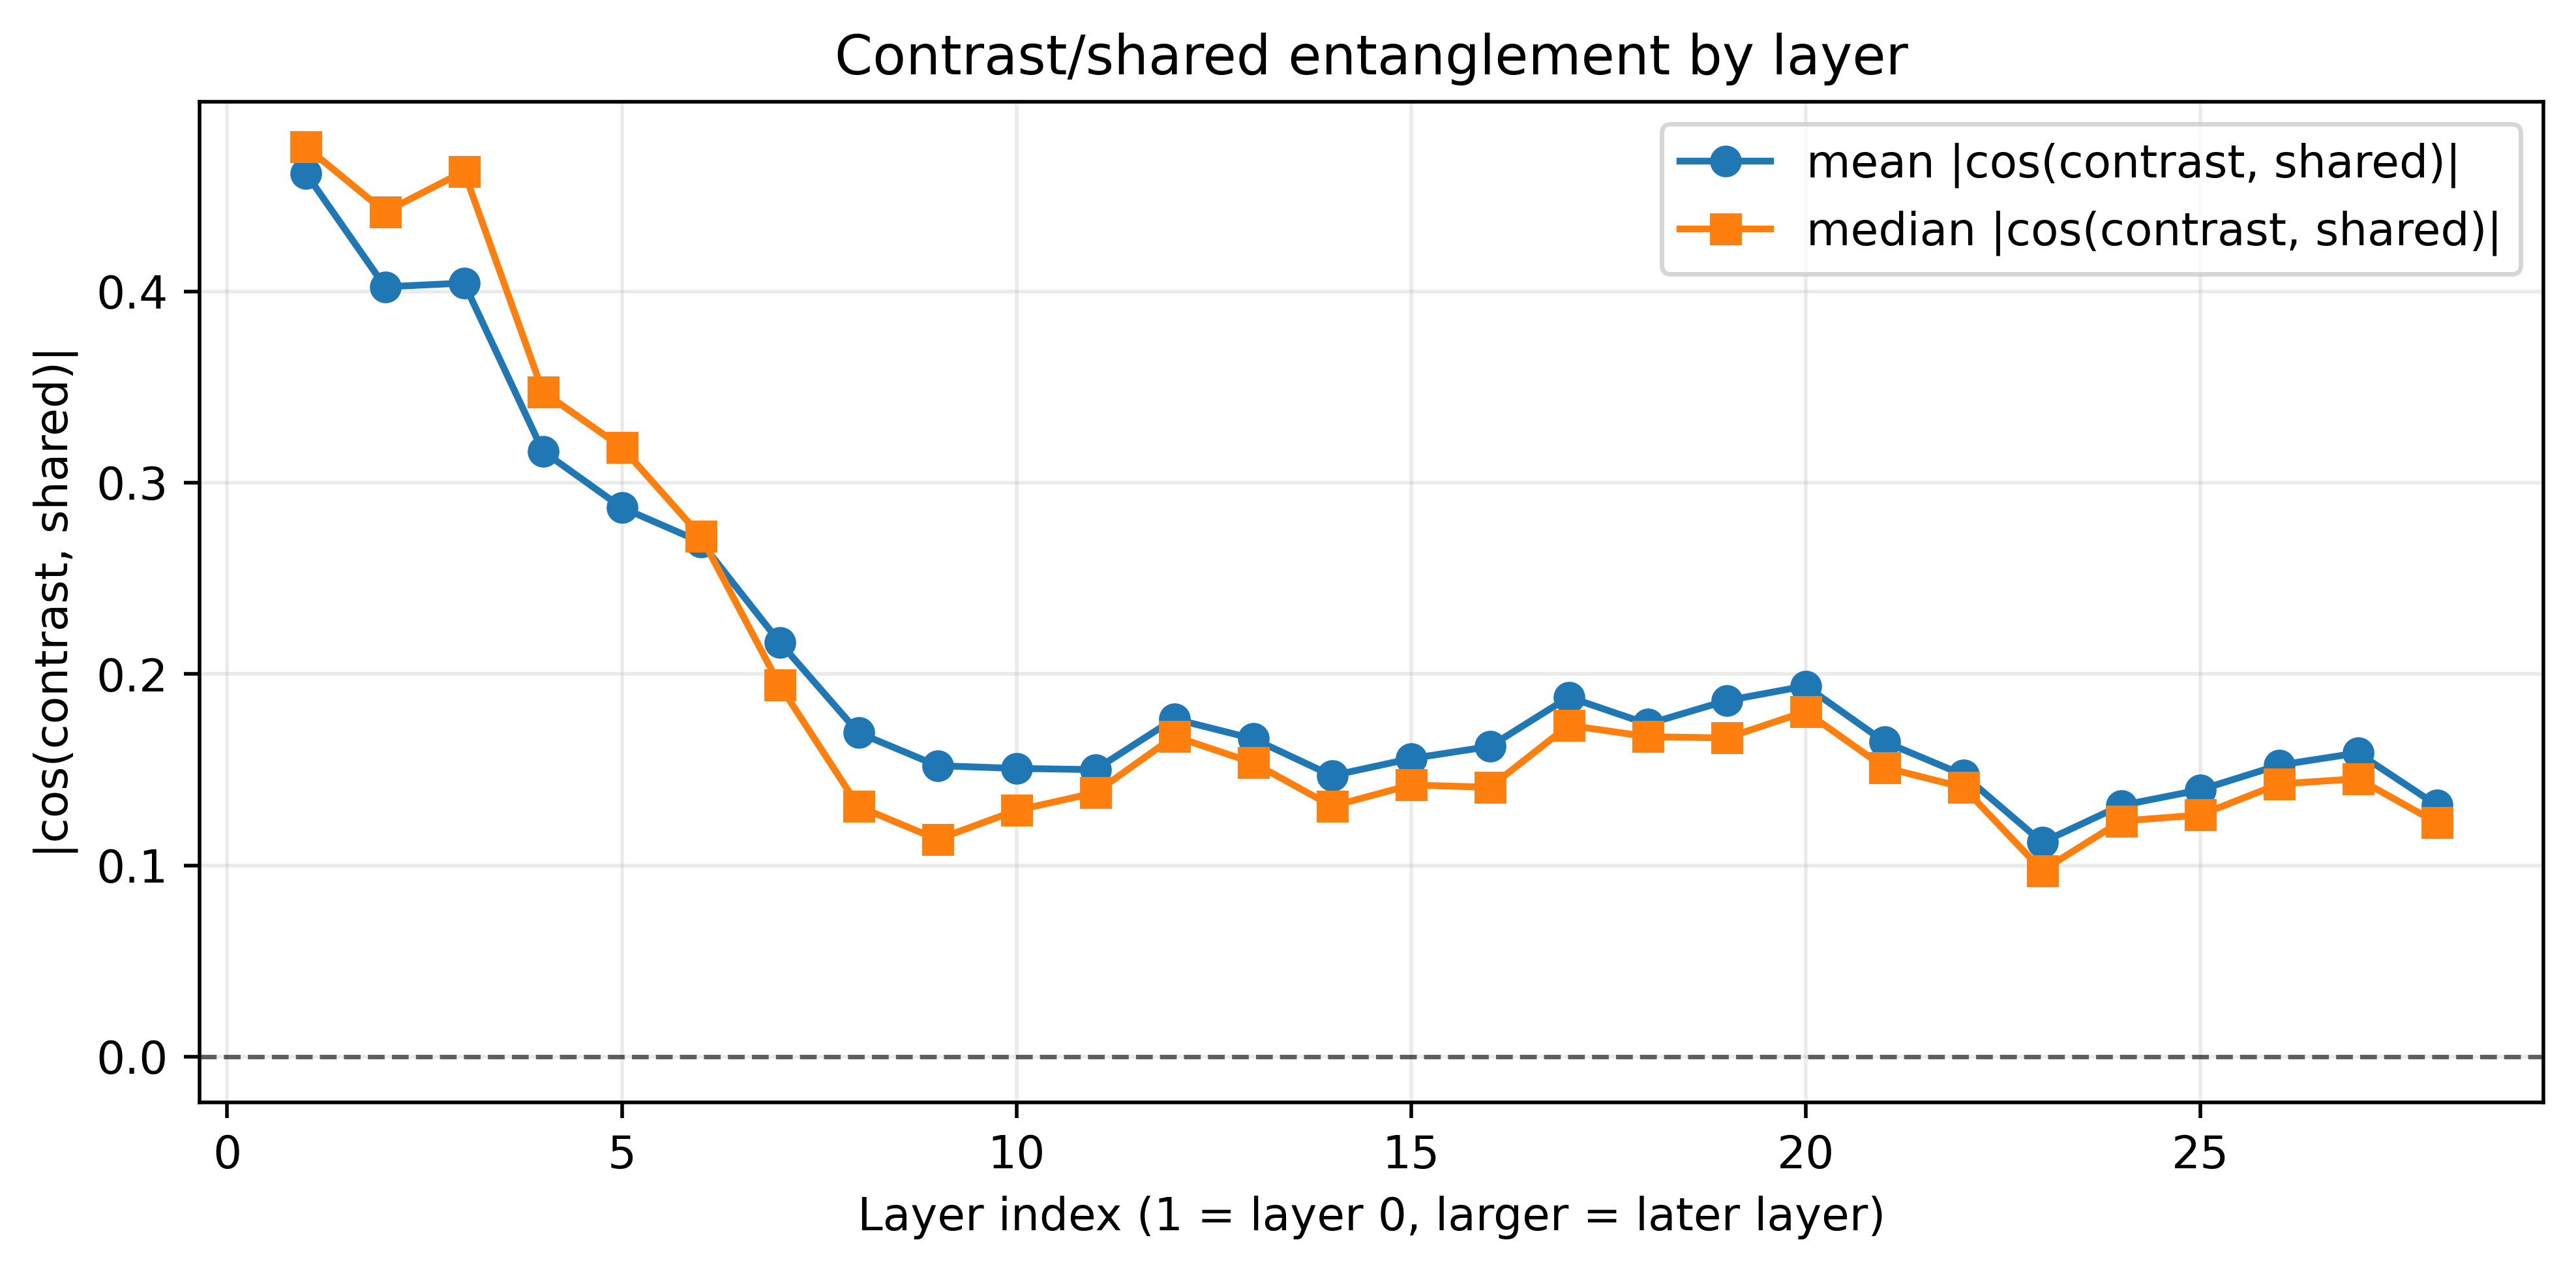

In [9]:
plt.figure(figsize=(8, 4), dpi=500)
plt.plot(contrast_layer_summary['layer_index'], contrast_layer_summary['mean_shared_norm'], marker='o', label='shared norm')
plt.plot(contrast_layer_summary['layer_index'], contrast_layer_summary['mean_contrast_norm'], marker='s', label='contrast norm')
plt.plot(contrast_layer_summary['layer_index'], contrast_layer_summary['mean_contrast_clean_norm'], marker='^', label='contrast clean norm')
plt.xlabel('Layer index (1 = layer 0, larger = later layer)')
plt.ylabel('Mean vector norm')
plt.title('Shared vs contrast signal strength by layer')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4), dpi=500)
plt.plot(
    contrast_layer_summary['layer_index'],
    contrast_layer_summary['mean_contrast_norm'] / contrast_layer_summary['mean_shared_norm'],
    marker='o',
    label='mean contrast norm / mean shared norm',
)
plt.plot(
    contrast_layer_summary['layer_index'],
    contrast_layer_summary['mean_contrast_to_shared_norm_ratio'],
    marker='s',
    label='mean pairwise contrast/shared norm ratio',
)
plt.axhline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.6)
plt.xlabel('Layer index (1 = layer 0, larger = later layer)')
plt.ylabel('Contrast/shared norm ratio')
plt.title('Contrast norm relative to shared norm by layer')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4), dpi=500)
plt.plot(
    contrast_layer_summary['layer_index'],
    contrast_layer_summary['mean_abs_contrast_shared_cos'],
    marker='o',
    label='mean |cos(contrast, shared)|',
)
plt.plot(
    contrast_layer_summary['layer_index'],
    contrast_layer_summary['median_abs_contrast_shared_cos'],
    marker='s',
    label='median |cos(contrast, shared)|',
)
plt.axhline(0.0, color='black', linewidth=1, linestyle='--', alpha=0.6)
plt.xlabel('Layer index (1 = layer 0, larger = later layer)')
plt.ylabel('|cos(contrast, shared)|')
plt.title('Contrast/shared entanglement by layer')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
OUTPUT_DIR = Path('contrast_sanity_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

contrast_normal_layer_order_all = (
    contrast_df
    .sort_values(['layer_index', 'category_key', 'pair_slug'])
    .reset_index(drop=True)
)

results_normal_layer_order_all = (
    results_df
    .sort_values(['layer_index', 'category_key', 'pair_slug'])
    .reset_index(drop=True)
)

contrast_normal_layer_order_all.to_csv(OUTPUT_DIR / 'contrast_sanity_all.csv', index=False)
contrast_layer_summary.to_csv(OUTPUT_DIR / 'contrast_layer_summary.csv', index=False)
contrast_normal_layer_order_all.to_csv(OUTPUT_DIR / 'contrast_normal_layer_order_all.csv', index=False)
results_normal_layer_order_all.to_csv(OUTPUT_DIR / 'cosine_normal_layer_order_all.csv', index=False)

# Overwrite earlier metric-sorted filenames too, so stale CSVs do not keep the old ordering.
contrast_normal_layer_order_all.to_csv(OUTPUT_DIR / 'most_entangled_all.csv', index=False)
contrast_normal_layer_order_all.to_csv(OUTPUT_DIR / 'weakest_contrast_all.csv', index=False)
contrast_normal_layer_order_all.to_csv(OUTPUT_DIR / 'strongest_contrast_all.csv', index=False)

print(f'Saved normal-layer-order outputs to: {OUTPUT_DIR.resolve()}')
display(contrast_normal_layer_order_all.head(50)[[
    'category_key',
    'concept_label',
    'layer_index',
    'layer',
    'contrast_to_shared_cos',
    'abs_contrast_shared_cos',
    'contrast_norm',
    'shared_norm',
    'contrast_to_shared_norm_ratio',
    'contrast_clean_to_contrast_norm_ratio',
]])

Saved normal-layer-order outputs to: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/contrast_sanity_outputs


,category_key,concept_label,layer_index,layer,contrast_to_shared_cos,abs_contrast_shared_cos,contrast_norm,shared_norm,contrast_to_shared_norm_ratio,contrast_clean_to_contrast_norm_ratio
0,ideology,centralization-support vs decentralization-sup...,1,-35,0.649999,0.649999,0.804887,1.184815,0.679335,0.759936
1,ideology,collective-benefit vs personal-benefit,1,-35,0.632889,0.632889,0.843929,1.175941,0.717663,0.774243
2,ideology,collective-responsibility vs individual-respon...,1,-35,0.705007,0.705007,0.838151,1.146740,0.730899,0.709201
3,ideology,collective-security vs civil-liberty,1,-35,0.567296,0.567296,0.818021,1.254899,0.651862,0.823514
4,ideology,collective-welfare vs individual-liberty,1,-35,0.675792,0.675792,0.882105,1.207566,0.730482,0.737092
5,ideology,competition-policy vs cooperation-policy,1,-35,0.646550,0.646550,0.826336,1.395769,0.592029,0.762871
6,ideology,consumer-protection vs corporate-freedom,1,-35,0.610274,0.610274,1.058861,1.289582,0.821089,0.792191
7,ideology,data-protection-priority vs data-utilization-p...,1,-35,0.571835,0.571835,1.051959,1.127217,0.933235,0.820369
8,ideology,economic-growth-priority vs sustainability-pri...,1,-35,0.516431,0.516431,1.186797,1.181550,1.004441,0.856329
9,ideology,energy-transition vs fossil-energy-support,1,-35,0.516069,0.516069,0.818285,1.299820,0.629537,0.856547


In [10]:
STEERING_VECTOR_OUTPUT_ROOT = Path('contrastive_hidden_states/data/steering_vectors') / ROOT.name

STEERING_DIRECTIONS = {
    'base_to_pos': lambda pos_mean, base_mean, neg_mean: pos_mean - base_mean,
    'base_to_neg': lambda pos_mean, base_mean, neg_mean: neg_mean - base_mean,
    'pos_to_neg': lambda pos_mean, base_mean, neg_mean: neg_mean - pos_mean,
    'neg_to_pos': lambda pos_mean, base_mean, neg_mean: pos_mean - neg_mean,
}


def save_steering_vectors(
    root: Path,
    output_root: Path,
    directions: dict = STEERING_DIRECTIONS,
) -> pd.DataFrame:
    """Save per-pair steering vectors as [num_extracted_layers, hidden_dim] .npy files."""
    rows = []

    for pair_info in iter_pair_infos(root):
        pair_dir = pair_info['pair_dir']
        category_key = pair_info['category_key']
        pair_slug = pair_info['pair_slug']
        layers = sorted(pair_info['layers'])
        expected_layers = list(range(len(layers)))
        if layers != expected_layers:
            raise ValueError(
                f"{pair_slug} has source layers {layers}; expected zero-based contiguous layers {expected_layers}. "
                "Regenerate hidden states with the updated positive layer indexing before saving steering vectors."
            )
        layer_vectors = {direction: [] for direction in directions}

        for layer in layers:
            positive = load_layer_matrix(pair_dir, 'positive', layer)
            base = load_layer_matrix(pair_dir, 'base', layer)
            negative = load_layer_matrix(pair_dir, 'negative', layer)

            pos_mean = positive.mean(axis=0)
            base_mean = base.mean(axis=0)
            neg_mean = negative.mean(axis=0)

            for direction, direction_fn in directions.items():
                vector = direction_fn(pos_mean, base_mean, neg_mean)
                layer_vectors[direction].append(vector.astype(np.float32))

        save_dir = output_root / category_key / pair_slug
        save_dir.mkdir(parents=True, exist_ok=True)

        metadata = {
            'category_key': category_key,
            'category_name': pair_info['category_name'],
            'pair_slug': pair_slug,
            'positive_concept': pair_info['positive_concept'],
            'negative_concept': pair_info['negative_concept'],
            'source_pair_dir': str(pair_dir),
            'source_layers': layers,
            'vllm_layer_order': layers,
            'directions': sorted(directions),
        }
        (save_dir / 'metadata.json').write_text(
            json.dumps(metadata, indent=2, ensure_ascii=False),
            encoding='utf-8',
        )

        for direction, vectors_for_layers in layer_vectors.items():
            vectors = np.stack(vectors_for_layers, axis=0)
            save_path = save_dir / f'{direction}.npy'
            np.save(save_path, vectors)

            rows.append({
                'category_key': category_key,
                'category_name': pair_info['category_name'],
                'pair_slug': pair_slug,
                'concept_label': f"{pair_info['positive_concept']} vs {pair_info['negative_concept']}",
                'positive_concept': pair_info['positive_concept'],
                'negative_concept': pair_info['negative_concept'],
                'direction': direction,
                'num_layers': vectors.shape[0],
                'hidden_dim': vectors.shape[1],
                'path': str(save_path),
            })

    manifest_df = pd.DataFrame(rows).sort_values(['category_key', 'pair_slug', 'direction'])
    output_root.mkdir(parents=True, exist_ok=True)
    manifest_df.to_csv(output_root / 'manifest.csv', index=False)
    return manifest_df


steering_manifest_df = save_steering_vectors(ROOT, STEERING_VECTOR_OUTPUT_ROOT)

print(f'Saved {len(steering_manifest_df)} steering vector files to: {STEERING_VECTOR_OUTPUT_ROOT.resolve()}')
display(steering_manifest_df.head(20))



Saved 600 steering vector files to: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/contrastive_hidden_states/data/steering_vectors/Qwen2.5-1.5B-Instruct


,category_key,category_name,pair_slug,concept_label,positive_concept,negative_concept,direction,num_layers,hidden_dim,path
1,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,base_to_neg,28,1536,contrastive_hidden_states/data/steering_vector...
0,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,base_to_pos,28,1536,contrastive_hidden_states/data/steering_vector...
3,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,neg_to_pos,28,1536,contrastive_hidden_states/data/steering_vector...
2,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,pos_to_neg,28,1536,contrastive_hidden_states/data/steering_vector...
5,ideology,IDEOLOGY,ideology__collective_benefit__personal_benefit,collective-benefit vs personal-benefit,collective-benefit,personal-benefit,base_to_neg,28,1536,contrastive_hidden_states/data/steering_vector...
4,ideology,IDEOLOGY,ideology__collective_benefit__personal_benefit,collective-benefit vs personal-benefit,collective-benefit,personal-benefit,base_to_pos,28,1536,contrastive_hidden_states/data/steering_vector...
7,ideology,IDEOLOGY,ideology__collective_benefit__personal_benefit,collective-benefit vs personal-benefit,collective-benefit,personal-benefit,neg_to_pos,28,1536,contrastive_hidden_states/data/steering_vector...
6,ideology,IDEOLOGY,ideology__collective_benefit__personal_benefit,collective-benefit vs personal-benefit,collective-benefit,personal-benefit,pos_to_neg,28,1536,contrastive_hidden_states/data/steering_vector...
9,ideology,IDEOLOGY,ideology__collective_responsibility__individua...,collective-responsibility vs individual-respon...,collective-responsibility,individual-responsibility,base_to_neg,28,1536,contrastive_hidden_states/data/steering_vector...
8,ideology,IDEOLOGY,ideology__collective_responsibility__individua...,collective-responsibility vs individual-respon...,collective-responsibility,individual-responsibility,base_to_pos,28,1536,contrastive_hidden_states/data/steering_vector...
